✅ RAPIDS cuML detected (GPU Acceleration Enabled)
   K-MEANS PARAMETER TUNING (Sample: 100,000)
Loading data from: /kaggle/input/sentence-embeddings-dataset/sentence_embeddings.parquet
Sliced to first 100,000 rows.
Stacking vectors...
Moving to GPU...
Running PCA (384 -> 50 dims)...

Starting K-Means Grid Search...
Note: Noise will always be 0%. We look for the best Silhouette Score.
-----------------------------------------------------------------
K (Clusters)    | Inertia         | Silhouette   | Time (s)  
-----------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


5               | 4.25e+04        | 0.0560       | 1.60      


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


10              | 3.77e+04        | 0.0792       | 1.06      


...

50              | 2.97e+04        | 0.0802       | 1.11      


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


60              | 2.90e+04        | 0.0808       | 1.07      


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


80              | 2.79e+04        | 0.0756       | 1.07      
-----------------------------------------------------------------

Generating Elbow Plot...
✅ Plot saved to: kmeans_elbow_plot.png

💡 Recommendation:
1. Look for a high Silhouette Score.
2. Look for the 'Elbow' in the generated graph (where the line flattens out).
3. Generally, for 4.7M sentences, k=500 to k=2000 is often a good range.


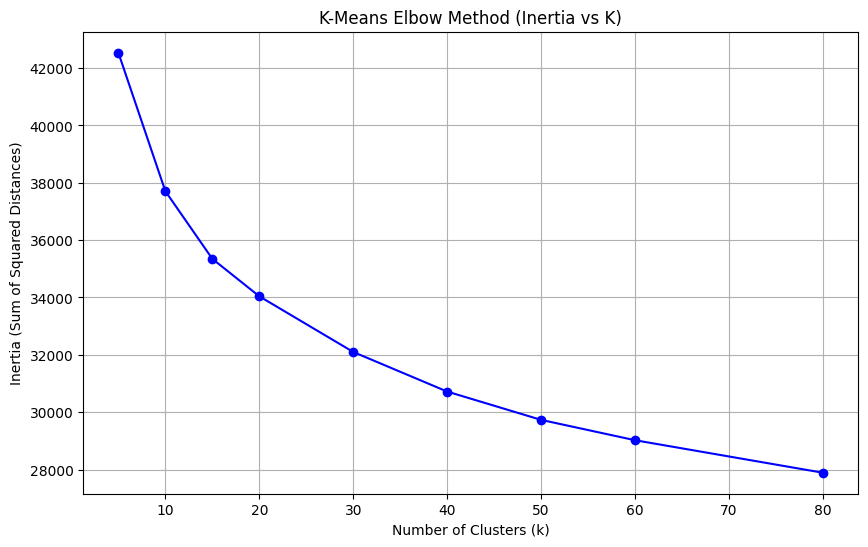

In [1]:
import pandas as pd
import numpy as np
import os
import time
import gc
import sys
import matplotlib.pyplot as plt # Added for plotting

# --- Check for GPU Acceleration ---
try:
    import cudf
    from cuml.cluster import KMeans
    from cuml.decomposition import PCA
    from sklearn.metrics import silhouette_score
    print("✅ RAPIDS cuML detected (GPU Acceleration Enabled)")
except ImportError:
    print("❌ ERROR: RAPIDS cuML not found.")
    print("ACTION REQUIRED: Go to Settings -> Accelerator -> Select 'GPU T4 x2'")
    sys.exit(1)

# --- Configuration ---
SAMPLE_SIZE = 100000  # Process 100k rows for tuning
INPUT_FILE_NAME = "sentence_embeddings.parquet"

# Define the number of clusters (k) to test
# UPDATED: Testing smaller ranges more suitable for broad financial themes
K_VALUES_TO_TEST = [5, 10, 15, 20, 30, 40, 50, 60, 80]

def find_embeddings_file():
    search_paths = [
        f"/kaggle/input/sentence-embeddings-dataset/{INPUT_FILE_NAME}",
        f"/kaggle/working/{INPUT_FILE_NAME}",
        INPUT_FILE_NAME
    ]
    for path in search_paths:
        if os.path.exists(path):
            return path
    for root, dirs, files in os.walk("/kaggle/input"):
        for file in files:
            if file.endswith(INPUT_FILE_NAME):
                return os.path.join(root, file)
    return None

def main():
    print("="*60)
    print(f"   K-MEANS PARAMETER TUNING (Sample: {SAMPLE_SIZE:,})")
    print("="*60)

    # --- 1. Load Data ---
    input_file = find_embeddings_file()
    if input_file is None:
        print("❌ Error: Embeddings file not found.")
        return

    print(f"Loading data from: {input_file}")
    
    # Read just a sample
    df = pd.read_parquet(input_file, columns=['embedding'])
    
    if len(df) > SAMPLE_SIZE:
        df = df.head(SAMPLE_SIZE)
        print(f"Sliced to first {SAMPLE_SIZE:,} rows.")
    else:
        print(f"Using full dataset ({len(df):,} rows).")

    # Stack to numpy float32
    print("Stacking vectors...")
    embeddings = np.stack(df['embedding'].values).astype('float32')
    
    # Move to GPU
    print("Moving to GPU...")
    X_gpu = cudf.DataFrame(embeddings)
    
    # Clean up CPU memory
    del df, embeddings
    gc.collect()

    # --- 2. PCA (Optional but recommended for speed/quality) ---
    print("Running PCA (384 -> 50 dims)...")
    pca = PCA(n_components=50)
    X_reduced = pca.fit_transform(X_gpu)
    
    print("\nStarting K-Means Grid Search...")
    print("Note: Noise will always be 0%. We look for the best Silhouette Score.")
    print("-" * 65)
    print(f"{'K (Clusters)':<15} | {'Inertia':<15} | {'Silhouette':<12} | {'Time (s)':<10}")
    print("-" * 65)

    # Lists to store results for plotting
    k_values = []
    inertia_values = []

    # --- 3. Run Experiments ---
    for k in K_VALUES_TO_TEST:
        try:
            start_t = time.time()
            
            # Initialize KMeans
            kmeans = KMeans(n_clusters=k, random_state=42)
            
            # Fit & Predict
            clusters = kmeans.fit_predict(X_reduced)
            
            # Calculate Metrics
            # Inertia: Sum of squared distances to closest centroid (lower is better)
            inertia = kmeans.inertia_
            
            # Store for plotting
            k_values.append(k)
            inertia_values.append(inertia)
            
            # Silhouette Score: How distinct the clusters are (-1 to 1, higher is better)
            # We calculate this on CPU using a subsample because it's expensive O(N^2)
            # We use the X_reduced (GPU) converted to numpy for scoring
            if k <= 1000: # Only calc silhouette for reasonable k sizes to save time
                labels_sample = clusters.to_numpy()
                X_sample_cpu = X_reduced.to_numpy()
                
                # Use a smaller subsample for the score calculation to be fast
                score_sample_size = min(10000, len(labels_sample))
                sil_score = silhouette_score(
                    X_sample_cpu, 
                    labels_sample, 
                    metric='euclidean', 
                    sample_size=score_sample_size
                )
                sil_str = f"{sil_score:.4f}"
            else:
                sil_str = "Skipped"

            duration = time.time() - start_t
            
            # Print Row
            print(f"{k:<15} | {inertia:<15.2e} | {sil_str:<12} | {duration:<10.2f}")
            
            # Cleanup
            del clusters, kmeans
            gc.collect()
            
        except Exception as e:
            print(f"{k:<15} | {'FAILED':<15} | {'-':<12} | -")
            print(f"Error: {e}")

    print("-" * 65)
    
    # --- 4. Generate Elbow Plot ---
    print("\nGenerating Elbow Plot...")
    try:
        plt.figure(figsize=(10, 6))
        plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
        plt.title('K-Means Elbow Method (Inertia vs K)')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Inertia (Sum of Squared Distances)')
        plt.grid(True)
        
        output_plot = 'kmeans_elbow_plot.png'
        plt.savefig(output_plot)
        print(f"✅ Plot saved to: {output_plot}")
    except Exception as e:
        print(f"❌ Error generating plot: {e}")

    print("\n💡 Recommendation:")
    print("1. Look for a high Silhouette Score.")
    print("2. Look for the 'Elbow' in the generated graph (where the line flattens out).")
    print("3. Generally, for 4.7M sentences, k=500 to k=2000 is often a good range.")

if __name__ == "__main__":
    main()

In [2]:
import pandas as pd
import numpy as np
import os
import time
import gc
import sys
import subprocess
import torch
from collections import Counter

# --- 0. Install Missing Libraries ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import datasets
    from datasets import load_dataset
except ImportError:
    print("Installing datasets...")
    install("datasets")
    from datasets import load_dataset

try:
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import semantic_search
except ImportError:
    print("Installing sentence-transformers...")
    install("sentence-transformers")
    from sentence_transformers import SentenceTransformer
    from sentence_transformers.util import semantic_search

try:
    import nltk
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

# --- Check for GPU Acceleration ---
try:
    import cudf
    from cuml.cluster import KMeans
    from cuml.decomposition import PCA
    print("✅ RAPIDS cuML detected (GPU Acceleration Enabled)")
except ImportError:
    print("❌ ERROR: RAPIDS cuML not found.")
    print("ACTION REQUIRED: Go to Settings -> Accelerator -> Select 'GPU T4 x2'")
    sys.exit(1)

# --- Configuration ---
OUTPUT_UNIFIED_FILE = "final_unified_dataset.csv"
OUTPUT_IMPORTANCE_FILE = "document_cluster_importance.csv"
ORIGINAL_DATASET_HF = "datht/FINDSum"
NUM_CLUSTERS = 30  # Fixed K=30 based on your request

# --- 1. Auto-Discovery of Input File ---
def find_embeddings_file():
    search_paths = [
        "/kaggle/input/sentence-embeddings-dataset/sentence_embeddings.parquet",
        "/kaggle/working/sentence_embeddings.parquet",
        "sentence_embeddings.parquet"
    ]
    for path in search_paths:
        if os.path.exists(path):
            return path
    # Deep search
    for root, dirs, files in os.walk("/kaggle/input"):
        for file in files:
            if file.endswith("sentence_embeddings.parquet"):
                return os.path.join(root, file)
    return None

def main():
    print("="*60)
    print(f"   FINDSUM MASTER PIPELINE: K-MEANS (K={NUM_CLUSTERS})")
    print("="*60)

    # --- PART A: LOAD DATA ---
    input_file = find_embeddings_file()
    if input_file is None:
        print("❌ CRITICAL ERROR: Could not find 'sentence_embeddings.parquet'.")
        return

    print(f"\n[1/6] Loading Data from: {input_file}")
    df_doc = pd.read_parquet(input_file)
    print(f"Loaded {len(df_doc):,} document sentences.")
    
    # Extract embeddings for GPU processing
    print("Stacking vectors for GPU...")
    embeddings_cpu = np.stack(df_doc['embedding'].values).astype('float32')
    
    # Move to GPU for reduction & clustering
    X_gpu = cudf.DataFrame(embeddings_cpu)
    print(f"GPU Data Shape: {X_gpu.shape}")

    # --- PART B: DIMENSIONALITY REDUCTION & CLUSTERING ---
    print("\n[2/6] PCA & Clustering")
    
    # 1. PCA (384 -> 50)
    print("Running GPU PCA...")
    pca = PCA(n_components=50)
    X_reduced = pca.fit_transform(X_gpu)
    
    # 2. K-MEANS
    print(f"Running GPU K-Means (K={NUM_CLUSTERS})...")
    
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42)
    clusters = kmeans.fit_predict(X_reduced)
    
    # Get labels back to CPU
    doc_labels = clusters.to_numpy()
    
    # Assign labels to our main dataframe
    df_doc['cluster'] = doc_labels
    df_doc['source_type'] = 'document'
    
    print(f"✅ Clustering Complete.")
    print(f"   Clusters Created: {NUM_CLUSTERS}")
    print(f"   Noise: 0% (Guaranteed by K-Means)")

    # Clear GPU memory
    del X_gpu, X_reduced, clusters, kmeans, pca
    gc.collect()

    # --- PART C: CALCULATE CENTROIDS ---
    print("\n[3/6] Calculating True 384-Dim Centroids")
    # We use the original embeddings_cpu (384 dims) and the new doc_labels
    
    unique_clusters = np.unique(doc_labels)
    print(f"Calculating centroids for {len(unique_clusters)} clusters...")
    
    centroid_map = {}
    
    # Iterate and calculate mean
    for cid in unique_clusters:
        mask = (doc_labels == cid)
        # Calculate mean of original 384-dim vectors
        centroid_map[cid] = embeddings_cpu[mask].mean(axis=0)
        
    print("✅ Centroids calculated.")
    
    # Prepare for searching
    centroid_ids = np.array(list(centroid_map.keys()))
    centroid_matrix = np.stack(list(centroid_map.values()))
    
    # Free huge CPU embedding array
    del embeddings_cpu
    gc.collect()

    # --- PART D: PROCESS SUMMARIES ---
    print("\n[4/6] Processing Summaries from Hugging Face")
    dataset = load_dataset(ORIGINAL_DATASET_HF, split="train")
    
    # Get set of valid Doc IDs we have in our data
    valid_doc_ids = set(df_doc['doc_id'].unique())
    
    summary_data = []
    
    print("Tokenizing summaries...")
    for i, row in enumerate(dataset):
        if i not in valid_doc_ids: continue
        
        summary_text = row['summary']
        if not summary_text: continue
        
        summary_text = summary_text.replace("story_separator_special_tag", ". ")
        sents = nltk.sent_tokenize(summary_text)
        
        for idx, s in enumerate(sents):
            summary_data.append({
                'doc_id': i,
                'sentence_index': idx,
                'sentence': s
            })
            
    df_sum = pd.DataFrame(summary_data)
    print(f"Total Summary Sentences to map: {len(df_sum)}")

    # --- PART E: MAP SUMMARIES ---
    print("\n[5/6] Embedding & Mapping Summaries")
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
    
    print("Encoding summaries...")
    sum_embeddings = model.encode(
        df_sum['sentence'].tolist(),
        batch_size=128 if device == 'cuda' else 32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    print("Finding nearest cluster for each summary sentence...")
    hits = semantic_search(
        torch.from_numpy(sum_embeddings), 
        torch.from_numpy(centroid_matrix), 
        top_k=1
    )
    
    assigned_clusters = []
    for hit in hits:
        idx = hit[0]['corpus_id']
        assigned_clusters.append(centroid_ids[idx])
        
    df_sum['cluster'] = assigned_clusters
    df_sum['source_type'] = 'summary'

    # --- PART F: MERGE & SAVE ---
    print("\n[6/6] Merging and Saving")
    
    # Columns to unify
    cols = ['doc_id', 'sentence_index', 'sentence', 'cluster', 'source_type']
    
    # Concatenate
    df_final = pd.concat([df_doc[cols], df_sum[cols]], ignore_index=True)
    
    # Sort
    df_final = df_final.sort_values(['doc_id', 'source_type', 'sentence_index'])
    
    print(f"Saving {len(df_final):,} rows to {OUTPUT_UNIFIED_FILE}...")
    df_final.to_csv(OUTPUT_UNIFIED_FILE, index=False)
    
    # Calculate Importance
    print("Calculating Document Cluster Importance...")
    importance_data = []
    for doc_id, group in df_sum.groupby('doc_id'):
        counts = Counter(group['cluster'])
        for rank, (cid, hits) in enumerate(counts.most_common()):
            importance_data.append({
                'doc_id': doc_id,
                'importance_rank': rank + 1,
                'cluster_id': cid,
                'summary_hits': hits
            })
    
    df_imp = pd.DataFrame(importance_data)
    df_imp.to_csv(OUTPUT_IMPORTANCE_FILE, index=False)
    
    print("\n✅ PIPELINE COMPLETE!")
    print(f"1. Unified Dataset:      {OUTPUT_UNIFIED_FILE}")
    print(f"2. Cluster Importance:   {OUTPUT_IMPORTANCE_FILE}")

if __name__ == "__main__":
    main()

2025-11-30 05:41:28.984041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764481289.424554      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764481289.544179      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding summaries...


Batches:   0%|          | 0/5420 [00:00<?, ?it/s]

Finding nearest cluster for each summary sentence...

[6/6] Merging and Saving
Saving 5,375,911 rows to final_unified_dataset.csv...
Calculating Document Cluster Importance...

✅ PIPELINE COMPLETE!
1. Unified Dataset:      final_unified_dataset.csv
2. Cluster Importance:   document_cluster_importance.csv


In [3]:
import pandas as pd
import numpy as np
import os
import sys

# --- Configuration ---
# Input Files
UNIFIED_FILE = "final_unified_dataset.csv"
IMPORTANCE_FILE = "document_cluster_importance.csv"

# Output File
OUTPUT_FILE = "final_extracted_sentences.csv"

# Limit to top N clusters to avoid tail noise (e.g., Rank 50 with 1 summary hit)
TOP_N_CLUSTERS = 10 

def main():
    print("="*60)
    print(f"   EXTRACTING CONTENT (Matches Summary Count + Weighted Decay)")
    print("="*60)

    # --- 1. Load Data ---
    print(f"\n[1/5] Loading Datasets...")
    
    if not os.path.exists(UNIFIED_FILE) or not os.path.exists(IMPORTANCE_FILE):
        print("❌ Error: Input files not found.")
        return

    # Load Unified Data
    # Use pandas engine to avoid pyarrow errors if file was written with index
    df_content = pd.read_csv(UNIFIED_FILE)
    print(f"Loaded Unified Dataset: {len(df_content):,} rows")
    
    # Filter: Keep only DOCUMENT sentences
    df_content = df_content[df_content['source_type'] == 'document']
    
    # Load Rules
    df_imp = pd.read_csv(IMPORTANCE_FILE)
    print(f"Loaded Importance Rules: {len(df_imp):,} ranked clusters")

    # --- 2. Filter by Importance (Top N) ---
    print(f"\n[2/5] Merging and Filtering (Top {TOP_N_CLUSTERS})...")
    
    # Keep only ranks 1 to N
    df_imp_filtered = df_imp[df_imp['importance_rank'] <= TOP_N_CLUSTERS].copy()
    
    # Merge to attach 'importance_rank' AND 'summary_hits' to every sentence
    df_merged = pd.merge(
        df_content,
        # We now include 'summary_hits' to use as our minimum threshold
        df_imp_filtered[['doc_id', 'cluster_id', 'importance_rank', 'summary_hits']],
        left_on=['doc_id', 'cluster'],
        right_on=['doc_id', 'cluster_id'],
        how='inner'
    )
    
    # Drop redundant column
    df_merged.drop(columns=['cluster_id'], inplace=True)
    print(f"Candidates found: {len(df_merged):,} sentences matching important clusters.")

    # --- 3. Apply Selection Logic ---
    print("\n[3/5] Applying Selection Logic (Max(Summary Hits, Decay))...")
    
    # Sort to ensure we pick sentences in order of appearance (narrative flow)
    df_merged.sort_values(['doc_id', 'importance_rank', 'sentence_index'], inplace=True)
    
    # 1. Count how many sentences exist for each (Doc, Rank) group
    df_merged['group_size'] = df_merged.groupby(['doc_id', 'importance_rank'])['sentence'].transform('count')
    
    # 2. Assign a sequential counter (0, 1, 2...) to sentences within each group
    df_merged['local_idx'] = df_merged.groupby(['doc_id', 'importance_rank']).cumcount()
    
    # 3. Calculate Limit
    # Logic: We take the GREATER of:
    #    a) The 1/Rank decay amount (e.g. 50% for Rank 2)
    #    b) The number of times this cluster appeared in the summary ('summary_hits')
    
    decay_amount = df_merged['group_size'] / df_merged['importance_rank']
    df_merged['target_limit'] = np.maximum(decay_amount, df_merged['summary_hits'])
    
    # Convert to int
    df_merged['limit'] = df_merged['target_limit'].fillna(1).astype(int)
    
    # 4. Safety Net: Ensure we take AT LEAST 1 sentence, but NO MORE than available
    df_merged['limit'] = df_merged['limit'].clip(lower=1, upper=df_merged['group_size'])
    
    # --- BEFORE SNAPSHOT (Sample Doc 0) ---
    print("\n--- VISUALIZATION: BEFORE SELECTION (Doc 0) ---")
    doc0_before = df_merged[df_merged['doc_id'] == 0].copy()
    if not doc0_before.empty:
        print(f"Total Sentences Available: {len(doc0_before)}")
        # Show count per rank before
        print("Counts per Rank (Before):")
        print(doc0_before['importance_rank'].value_counts().sort_index())
    
    # 5. Apply Filter
    # Keep sentence if its index (0,1,2) is less than the calculated limit
    df_extracted = df_merged[df_merged['local_idx'] < df_merged['limit']].copy()
    
    # Stats
    total_candidates = len(df_merged)
    kept_sents = len(df_extracted)
    print(f"\nSelection Logic applied:")
    print(f"- Input Candidates: {total_candidates:,}")
    print(f"- Selected:         {kept_sents:,}")
    print(f"- Reduction:        Kept {(kept_sents/total_candidates)*100:.2f}% of candidate sentences")

    # --- AFTER SNAPSHOT (Sample Doc 0) ---
    print("\n--- VISUALIZATION: AFTER SELECTION (Doc 0) ---")
    doc0_after = df_extracted[df_extracted['doc_id'] == 0].copy()
    if not doc0_after.empty:
        print(f"Total Sentences Kept: {len(doc0_after)}")
        
        print("Comparison per Rank:")
        ranks = sorted(doc0_before['importance_rank'].unique())
        for r in ranks:
            before_count = len(doc0_before[doc0_before['importance_rank'] == r])
            after_count = len(doc0_after[doc0_after['importance_rank'] == r])
            
            # Get summary hits for this rank (just take first value since it's same for group)
            hits = doc0_before[doc0_before['importance_rank'] == r]['summary_hits'].iloc[0]
            
            print(f"   Rank {r} (Summary Hits: {hits}): {before_count} -> {after_count}")

        print("\nFirst 3 Selected Sentences:")
        for i, row in doc0_after.head(3).iterrows():
             print(f"   [Rank {row['importance_rank']}] {row['sentence'][:80]}...")

    # --- 4. Sorting & Formatting ---
    print("\n[4/5] Finalizing...")
    
    # Clean up temp columns
    cols_to_keep = ['doc_id', 'sentence', 'cluster', 'importance_rank', 'sentence_index', 'summary_hits']
    df_extracted = df_extracted[cols_to_keep]
    
    # Sort: Document -> Rank -> Original Order
    df_extracted = df_extracted.sort_values(['doc_id', 'importance_rank', 'sentence_index'])
    
    # --- 5. Saving ---
    print(f"\n[5/5] Saving to {OUTPUT_FILE}...")
    df_extracted.to_csv(OUTPUT_FILE, index=False)
    
    print(f"\n✅ SUCCESS!")

if __name__ == "__main__":
    main()

   EXTRACTING CONTENT (Matches Summary Count + Weighted Decay)

[1/5] Loading Datasets...
Loaded Unified Dataset: 5,375,911 rows
Loaded Importance Rules: 369,978 ranked clusters

[2/5] Merging and Filtering (Top 10)...
Candidates found: 1,018,289 sentences matching important clusters.

[3/5] Applying Selection Logic (Max(Summary Hits, Decay))...

--- VISUALIZATION: BEFORE SELECTION (Doc 0) ---
Total Sentences Available: 11
Counts per Rank (Before):
importance_rank
1     1
3    10
Name: count, dtype: int64

Selection Logic applied:
- Input Candidates: 1,018,289
- Selected:         566,154
- Reduction:        Kept 55.60% of candidate sentences

--- VISUALIZATION: AFTER SELECTION (Doc 0) ---
Total Sentences Kept: 4
Comparison per Rank:
   Rank 1 (Summary Hits: 4): 1 -> 1
   Rank 3 (Summary Hits: 1): 10 -> 3

First 3 Selected Sentences:
   [Rank 1] factors that could cause or contribute to these differences include , but are no...
   [Rank 3] overview we are a leading commercial real estat